# Ejercicio 2.14 — LSTM con Catch22

Se modela `total_internacional` y se compara con el mejor LSTM obtenido previamente para esa misma serie: el Modelo 1 del notebook 2. Se conserva el corte 70/30, una ventana de 12 meses, una LSTM de 50 unidades y Adam. Una ablación global sin Catch22 separa el efecto de usar siete series del aporte de las 22 características.

La comparación se realiza con el mejor modelo de la serie total, no con el menor RMSE absoluto entre todas las series. Los errores de América del Centro, Europa y la serie total no son comparables directamente porque sus escalas son diferentes.

> Los CSV contienen un perfil por serie calculado con los 210 meses. El experimento es **transductivo/exploratorio**, pues ese perfil resume también la prueba.

In [1]:
from pathlib import Path
import os,random,warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"]="2"; os.environ["TF_ENABLE_ONEDNN_OPTS"]="0"
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,LSTM,Dense
from tensorflow.keras.callbacks import EarlyStopping
warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid")
pd.set_option("display.float_format",lambda x:f"{x:,.2f}")
SEED=42; random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
try: tf.config.experimental.enable_op_determinism()
except Exception: pass
cwd=Path.cwd().resolve()
ROOT=next((p for p in [cwd,*cwd.parents] if (p/"data"/"series_mensuales.csv").exists()),None)
if ROOT is None: raise FileNotFoundError("No se encontró data/series_mensuales.csv")
print("Raíz:",ROOT,"| TensorFlow:",tf.__version__)

Raíz: C:\Users\sebas\OneDrive\Escritorio\Github\Data sciencie\Data-Science\L02_DL_series | TensorFlow: 2.21.0


## 1. Datos y diseño

Cada fila Catch22 describe una serie completa, no un mes. Se usa una **LSTM global**: cada muestra contiene 12 rezagos de una de las siete series y su firma Catch22 repetida en esos pasos. La entrada enriquecida tiene 23 canales (valor + 22 características); la repetición aporta contexto estático, no una variable mensual.

In [2]:
series=pd.read_csv(ROOT/"data"/"series_mensuales.csv",index_col="Fecha",parse_dates=True)
raw=pd.read_csv(ROOT/"data"/"catch22_features.csv",index_col="serie")
c22=pd.read_csv(ROOT/"data"/"catch22_features_scaled.csv",index_col="serie")
raw=raw.loc[series.columns]; c22=c22.loc[series.columns,raw.columns]
assert series.shape==(210,7) and raw.shape==c22.shape==(7,22)
assert np.isfinite(series.to_numpy(float)).all() and np.isfinite(c22.to_numpy(float)).all()
NTR=int(np.floor(.70*len(series))); LB=12
train,test=series.iloc[:NTR],series.iloc[NTR:]
scalers,z={},{}
for n in series:
    s=MinMaxScaler(); z[n]=s.fit_transform(train[[n]]).ravel(); scalers[n]=s
display(pd.DataFrame({"inicio":[train.index.min(),test.index.min()],
"fin":[train.index.max(),test.index.max()],"meses":[len(train),len(test)]},
index=["entrenamiento","prueba"]))
print("Series:",series.shape,"| Catch22:",raw.shape,"| escalado temporal solo con entrenamiento")

,inicio,fin,meses
entrenamiento,2009-01-01,2021-03-01,147
prueba,2021-04-01,2026-06-01,63


Series: (210, 7) | Catch22: (7, 22) | escalado temporal solo con entrenamiento


Ablación: (945, 12, 1) | Catch22: (945, 12, 23)
total_internacional    135
aerea                  135
terrestre              135
maritima               135
america_centro         135
america_norte          135
europa                 135


LSTM_global_sin_catch22 200 épocas; loss 0.007767


LSTM_global_catch22 47 épocas; loss 0.031597


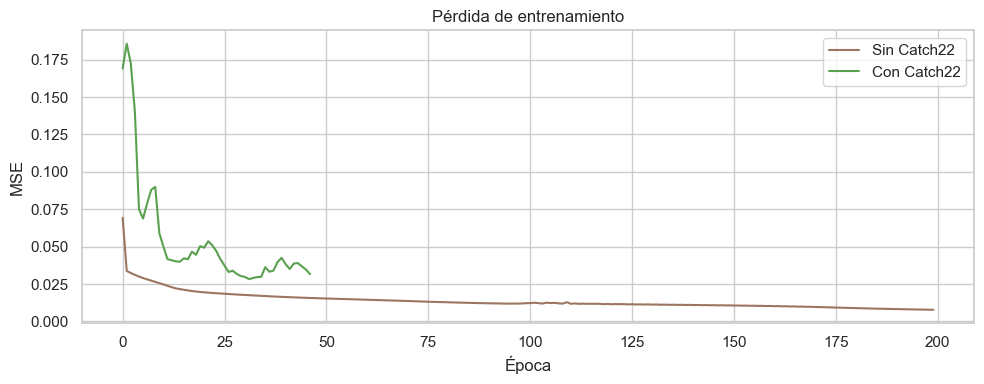

In [3]:
def muestras(con_c22):
    X, y, etiquetas = [], [], []
    for nombre in series.columns:
        perfil = c22.loc[nombre].to_numpy(dtype=np.float32)
        valores = z[nombre]
        for i in range(LB, len(valores)):
            rezagos = valores[i - LB:i].astype(np.float32)
            if con_c22:
                contexto = np.tile(perfil, (LB, 1))
                entrada = np.column_stack([rezagos, contexto])
            else:
                entrada = rezagos.reshape(-1, 1)
            X.append(entrada)
            y.append(valores[i])
            etiquetas.append(nombre)
    return np.asarray(X, np.float32), np.asarray(y, np.float32), etiquetas


def construir_modelo(n_features, nombre):
    modelo = Sequential([
        Input(shape=(LB, n_features)),
        LSTM(50, activation="tanh"),
        Dense(1),
    ], name=nombre)
    modelo.compile(optimizer="adam", loss="mse")
    return modelo


def entrenar(X, y, nombre):
    modelo = construir_modelo(X.shape[2], nombre)
    parada = EarlyStopping(
        monitor="loss", patience=15, min_delta=1e-5,
        restore_best_weights=True,
    )
    historia = modelo.fit(
        X, y, epochs=200, batch_size=16, shuffle=False,
        callbacks=[parada], verbose=0,
    )
    perdida_final = historia.history["loss"][-1]
    print(nombre, len(historia.history["loss"]), "épocas; loss", f"{perdida_final:.6f}")
    return modelo, historia


X0, y0, etiquetas = muestras(False)
Xc, yc, _ = muestras(True)
n_esperado = len(series.columns) * (NTR - LB)
assert X0.shape == (n_esperado, LB, 1)
assert Xc.shape == (n_esperado, LB, 23)
assert np.allclose(y0, yc)
print("Ablación:", X0.shape, "| Catch22:", Xc.shape)
print(pd.Series(etiquetas).value_counts().rename("ventanas").to_string())

# Se limpia la sesión una sola vez, antes de construir ambos modelos.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
m0, h0 = entrenar(X0, y0, "LSTM_global_sin_catch22")
mc, hc = entrenar(Xc, yc, "LSTM_global_catch22")

plt.figure(figsize=(10, 4))
plt.plot(h0.history["loss"], label="Sin Catch22", color="#9C755F")
plt.plot(hc.history["loss"], label="Con Catch22", color="#59A14F")
plt.title("Pérdida de entrenamiento")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Pronóstico recursivo y comparación

Como en el notebook 2, los 63 meses se pronostican recursivamente: cada predicción se realimenta y ningún valor real futuro entra como rezago. La referencia es el **Modelo 1**, seleccionado en el notebook 2 como el mejor LSTM de `total_internacional`: MAE 111,555.69; RMSE 126,235.75; MAPE 47.48%.

Los modelos geográficos del notebook 1 no se usan como referencia porque predicen series distintas. Aunque América del Centro obtuvo un RMSE absoluto menor, comparar esos valores directamente sería incorrecto debido a las diferencias de escala.

Comparacion de modelos:
                                 Ajuste                 Entradas        MAE       RMSE  MAPE %
Modelo                                                                                        
Global + Catch22               7 series  12 rezagos + 22 Catch22  79,014.63  89,244.22   56.65
LSTM base total - Modelo 1      1 serie               12 rezagos 111,555.69 126,235.75   47.48
Global sin Catch22 (ablacion)  7 series               12 rezagos 214,230.22 268,277.54   90.73


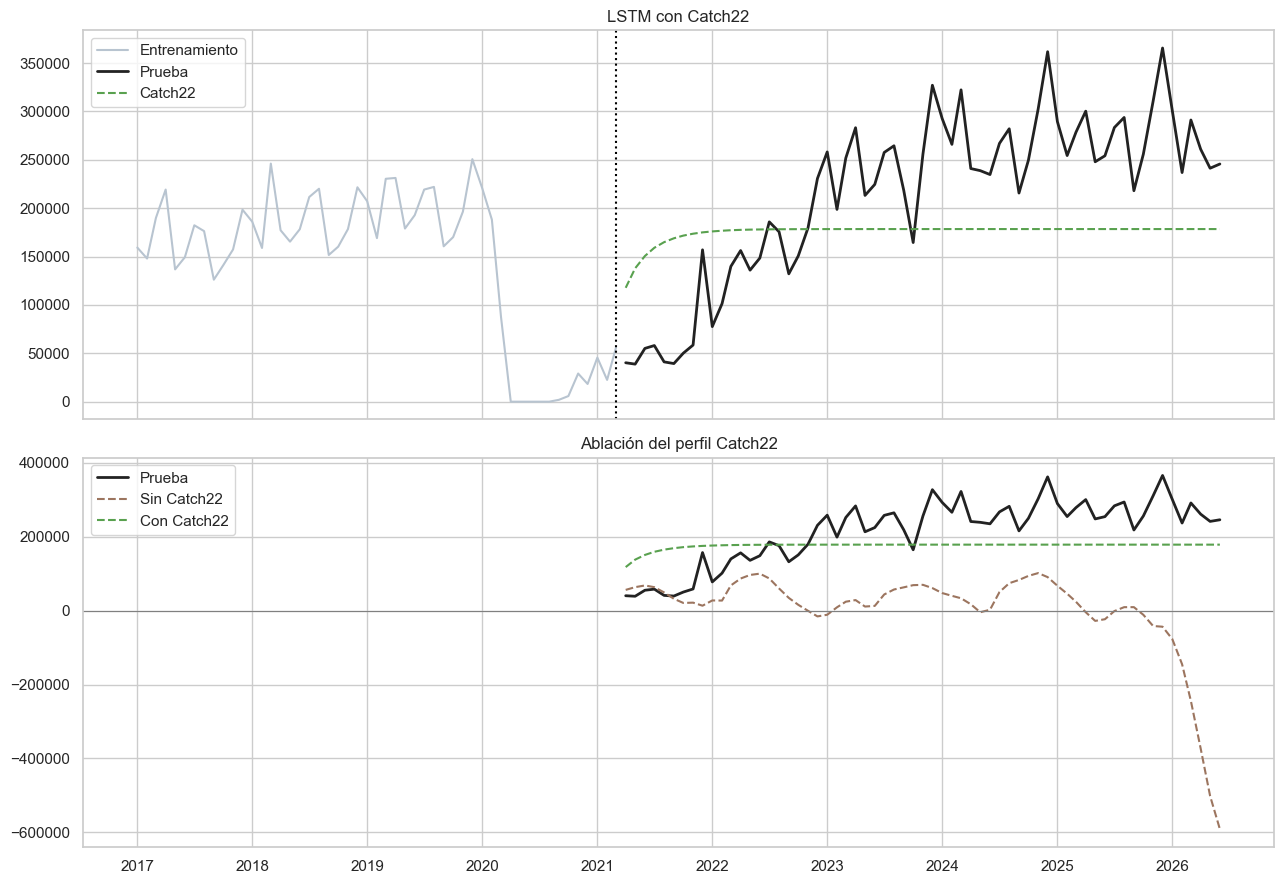


Discusion de resultados
LSTM global + Catch22: MAE=79,015, RMSE=89,244, MAPE=56.65%.
Reducción frente al LSTM base de la serie total: RMSE=29.3% y MAE=29.2%.
El MAPE empeora en 19.3% relativo.
Reduccion del RMSE frente a la ablacion global: 66.7%.
Catch22 funciona como firma estructural para distinguir las siete series.
El horizonte recursivo de 63 meses todavia suaviza el crecimiento y los picos finales.


In [4]:
OBJ = "total_internacional"


def pronosticar(modelo, con_c22):
    historial = list(z[OBJ])
    perfil = c22.loc[OBJ].to_numpy(dtype=np.float32)
    predicciones = []
    for _ in range(len(test)):
        rezagos = np.asarray(historial[-LB:], dtype=np.float32)
        if con_c22:
            contexto = np.tile(perfil, (LB, 1))
            entrada = np.column_stack([rezagos, contexto])[None, :, :]
        else:
            entrada = rezagos.reshape(1, LB, 1)
        siguiente = float(modelo.predict(entrada, verbose=0)[0, 0])
        predicciones.append(siguiente)
        historial.append(siguiente)
    valores = scalers[OBJ].inverse_transform(
        np.asarray(predicciones).reshape(-1, 1)
    ).ravel()
    return pd.Series(valores, index=test.index)


def metricas(real, prediccion):
    real = np.asarray(real, dtype=float)
    prediccion = np.asarray(prediccion, dtype=float)
    error = real - prediccion
    return {
        "MAE": np.mean(np.abs(error)),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "MAPE %": 100 * np.mean(np.abs(error) / real),
    }


p0 = pronosticar(m0, False)
pc = pronosticar(mc, True)
real = test[OBJ]

comparacion = pd.DataFrame([
    {
        "Modelo": "LSTM base total - Modelo 1",
        "Ajuste": "1 serie",
        "Entradas": "12 rezagos",
        "MAE": 111555.69,
        "RMSE": 126235.75,
        "MAPE %": 47.48,
    },
    {
        "Modelo": "Global sin Catch22 (ablacion)",
        "Ajuste": "7 series",
        "Entradas": "12 rezagos",
        **metricas(real, p0),
    },
    {
        "Modelo": "Global + Catch22",
        "Ajuste": "7 series",
        "Entradas": "12 rezagos + 22 Catch22",
        **metricas(real, pc),
    },
]).set_index("Modelo")

print("Comparacion de modelos:")
print(comparacion.sort_values("RMSE").round(2).to_string())

fig, ax = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
ax[0].plot(train[OBJ].loc["2017":], color="#B8C4D0", label="Entrenamiento")
ax[0].plot(real, color="#222222", lw=2, label="Prueba")
ax[0].plot(pc, color="#59A14F", ls="--", label="Catch22")
ax[0].axvline(train.index[-1], color="black", ls=":")
ax[0].set_title("LSTM con Catch22")
ax[0].legend()

ax[1].plot(real, color="#222222", lw=2, label="Prueba")
ax[1].plot(p0, color="#9C755F", ls="--", label="Sin Catch22")
ax[1].plot(pc, color="#59A14F", ls="--", label="Con Catch22")
ax[1].axhline(0, color="gray", lw=0.8)
ax[1].set_title("Ablación del perfil Catch22")
ax[1].legend()
plt.tight_layout()
plt.show()

referencia = comparacion.loc["LSTM base total - Modelo 1"]
ablacion = comparacion.loc["Global sin Catch22 (ablacion)"]
catch = comparacion.loc["Global + Catch22"]
mejora_rmse = 100 * (referencia["RMSE"] - catch["RMSE"]) / referencia["RMSE"]
mejora_mae = 100 * (referencia["MAE"] - catch["MAE"]) / referencia["MAE"]
mejora_mape = 100 * (referencia["MAPE %"] - catch["MAPE %"]) / referencia["MAPE %"]
mejora_ablacion = 100 * (ablacion["RMSE"] - catch["RMSE"]) / ablacion["RMSE"]

print()
print("Discusion de resultados")
print(f"LSTM global + Catch22: MAE={catch['MAE']:,.0f}, RMSE={catch['RMSE']:,.0f}, MAPE={catch['MAPE %']:.2f}%.")
print(f"Reducción frente al LSTM base de la serie total: RMSE={mejora_rmse:.1f}% y MAE={mejora_mae:.1f}%.")
if mejora_mape >= 0:
    print(f"El MAPE tambien se reduce en {mejora_mape:.1f}%.")
else:
    print(f"El MAPE empeora en {abs(mejora_mape):.1f}% relativo.")
print(f"Reduccion del RMSE frente a la ablacion global: {mejora_ablacion:.1f}%.")
print("Catch22 funciona como firma estructural para distinguir las siete series.")
print("El horizonte recursivo de 63 meses todavia suaviza el crecimiento y los picos finales.")

## 4. Conclusión y limitaciones

Catch22 reduce MAE y RMSE frente al mejor LSTM previamente obtenido para la misma serie total, mientras que el MAPE empeora. Por tanto, el resultado es mixto y no representa una mejora uniforme en todas las métricas. La ablación muestra además que el aporte no procede solo de aumentar las ventanas.

- **Elección de la referencia:** se utiliza el Modelo 1 del notebook 2 porque tanto ese modelo como la nueva LSTM con Catch22 pronostican `total_internacional`. Los LSTM geográficos son resultados válidos para sus propias series, pero no son una referencia directa para este objetivo.
- **Perfil transductivo:** la prueba no ajusta pesos ni se usa como rezago, pero el vector Catch22 resume la serie completa; las métricas pueden ser optimistas.
- **Comparación:** frente al modelo base cambian Catch22 y el entrenamiento global. La ablación permite observar por separado el comportamiento del diseño global sin las características.
